## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Loading

We load all monthly CRMLS export CSVs from Google Drive and concatenate them into a single DataFrame.

In [3]:
property_dfs = []
dir_path = '/content/drive/MyDrive/property_data'

for path in os.listdir(dir_path):
    property_dfs.append(pd.read_csv(os.path.join(dir_path, path), low_memory=False))

property_data = pd.concat(property_dfs, ignore_index=True)

# Filter to Single Family Residential only
property_data = property_data[
    (property_data['PropertyType'] == 'Residential') &
    (property_data['PropertySubType'] == 'SingleFamilyResidence')
]

print(f'Total records after property filter: {len(property_data):,}')

Total records after property filter: 130,210


## 3. Data Cleaning

### 3.1 Select Relevant Columns
We keep only columns that are available for off-market predictions, excluding `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, etc.

In [4]:
columns_to_keep = [
    'ClosePrice', 'CloseDate',
    # Structural features
    'LivingArea', 'BuildingAreaTotal', 'BedroomsTotal', 'BathroomsTotalInteger',
    'LotSizeSquareFeet', 'LotSizeAcres', 'Stories', 'MainLevelBedrooms',
    'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
    # Property attributes
    'YearBuilt', 'TaxYear', 'TaxAnnualAmount',
    'FireplacesTotal', 'AssociationFee', 'AssociationFeeFrequency',
    'ParkingTotal', 'AttachedGarageYN', 'NewConstructionYN',
    # Amenities (binary)
    'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'Flooring',
    # Location
    'City', 'PostalCode', 'MLSAreaMajor',
    # Agent/office info (for reference, not used in models)
    'BuyerAgentAOR', 'BuyerOfficeName', 'CoListOfficeName', 'BuilderName'
]

property_data = property_data[[c for c in columns_to_keep if c in property_data.columns]].copy()

### 3.2 Basic Quality Filters

Remove rows with missing targets, duplicates, and logically invalid records (e.g., zero bedrooms, tiny living area).

In [5]:
initial_rows = len(property_data)

property_data.dropna(subset=['ClosePrice'], inplace=True)
property_data['CloseDate'] = pd.to_datetime(property_data['CloseDate'])
property_data.drop_duplicates(inplace=True)

valid_mask = (
    (property_data['ClosePrice'] > 0) &
    (property_data['LivingArea'] > 100) &
    (property_data['BedroomsTotal'] > 0) &
    (property_data['BathroomsTotalInteger'] > 0)
)
property_data = property_data[valid_mask].copy()

print(f'Records removed: {initial_rows - len(property_data):,}')
print(f'Clean records remaining: {len(property_data):,}')

Records removed: 232
Clean records remaining: 129,978


## 4. Train / Test Split (Time-Based)

Per project requirements, we use a **temporal split** rather than a random split:
- **Test set:** the most recent (last) month of transactions in the dataset
- **Training set:** all months prior to the test month (minimum 6 months)

In [6]:
latest_month = property_data['CloseDate'].dt.to_period('M').max()
print(f'Test month: {latest_month}')

test_set = property_data[property_data['CloseDate'].dt.to_period('M') == latest_month].copy()
train_set = property_data[property_data['CloseDate'] < test_set['CloseDate'].min()].copy()

print(f'Train size: {len(train_set):,}')
print(f'Test size: {len(test_set):,}')

Test month: 2025-12
Train size: 119,534
Test size:  10,444


### 4.1 Outlier Removal (Within Each Split)

We remove the top and bottom 0.5% of `ClosePrice` values **independently** within each split. Thresholds are computed within each set to prevent cross-split leakage.

In [7]:
def remove_price_outliers(df):
    low = df['ClosePrice'].quantile(0.005)
    high = df['ClosePrice'].quantile(0.995)
    return df[(df['ClosePrice'] >= low) & (df['ClosePrice'] <= high)].copy()

train_set = remove_price_outliers(train_set)
test_set = remove_price_outliers(test_set)

print(f'Train after outlier removal: {len(train_set):,}')
print(f'Test after outlier removal:  {len(test_set):,}')

Train after outlier removal: 118,379
Test after outlier removal:  10,338


## 5. Exploratory Data Analysis

Before modeling, we explore the distribution of key variables and their relationship to `ClosePrice`.

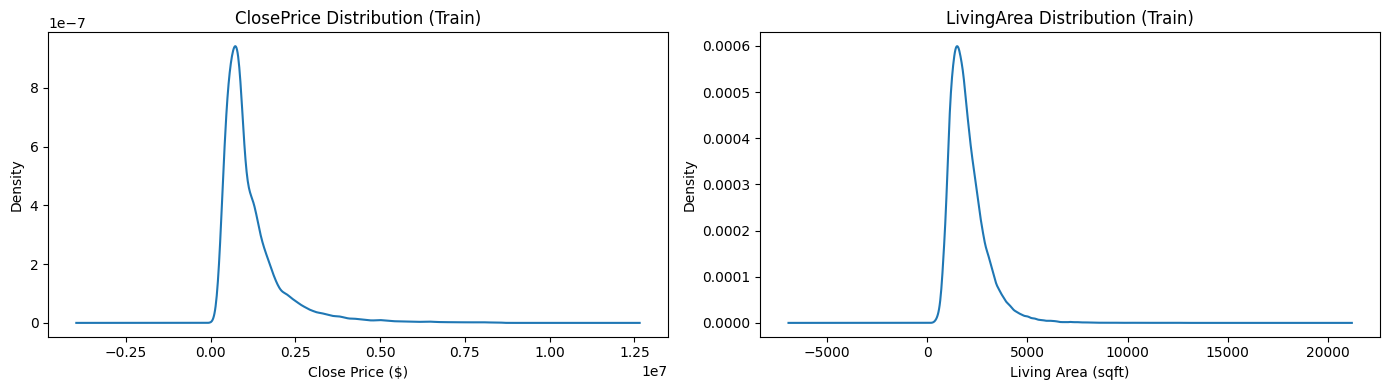

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_set['ClosePrice'].plot.kde(ax=axes[0], title='ClosePrice Distribution (Train)')
axes[0].set_xlabel('Close Price ($)')
train_set['LivingArea'].plot.kde(ax=axes[1], title='LivingArea Distribution (Train)')
axes[1].set_xlabel('Living Area (sqft)')
plt.tight_layout()
plt.show()

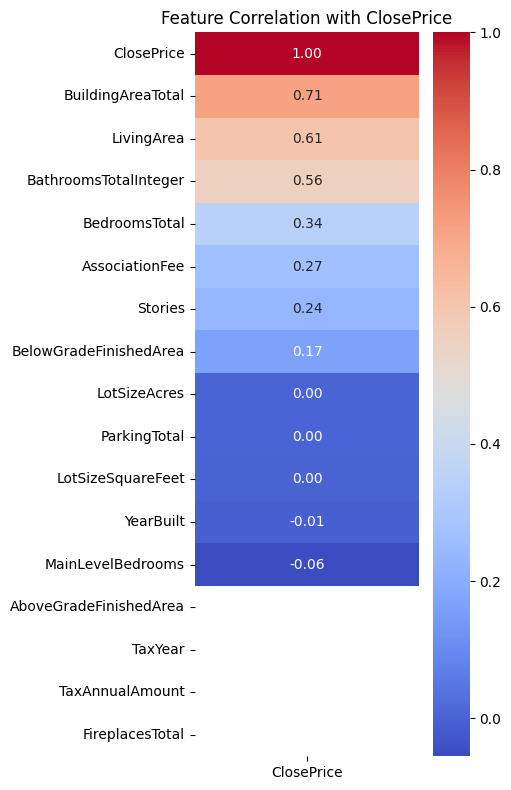

In [9]:
# Correlation with ClosePrice
corr = train_set.corr(numeric_only=True)['ClosePrice'].sort_values(ascending=False).to_frame()
plt.figure(figsize=(5, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation with ClosePrice')
plt.tight_layout()
plt.show()

In [10]:
# Missing values in training set
missing = train_set.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
TaxYear,118379
TaxAnnualAmount,118379
FireplacesTotal,118379
AboveGradeFinishedArea,118379
WaterfrontYN,118322
BelowGradeFinishedArea,117574
BasementYN,115572
BuilderName,112817
BuildingAreaTotal,110748
CoListOfficeName,88711


## 6. Feature Engineering & Preprocessing

### 6.1 Feature Selection

In [25]:
features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeSquareFeet',
    'AssociationFee',
    'BuildingAreaTotal',
    'Stories',
    'MainLevelBedrooms',
    'City'
]

X_train = train_set[features].copy()
y_train = train_set['ClosePrice']

X_test = test_set[features].copy()
y_test = test_set['ClosePrice']

In [26]:
# Group rare cities — keep only cities with > 100 training examples
city_counts = X_train['City'].value_counts()
top_cities = city_counts[city_counts > 100].index

X_train['City'] = X_train['City'].where(X_train['City'].isin(top_cities), 'Other')
X_test['City'] = X_test['City'].where(X_test['City'].isin(top_cities), 'Other')

print(f'Unique city categories after grouping: {X_train["City"].nunique()}')

Unique city categories after grouping: 280


### 6.2 Encoding & Imputation

- **One-hot encoding** for `City` (categorical)
- **Median imputation** for numeric columns — using training statistics only to avoid leakage
- Test columns are aligned to training columns so no unseen city causes a mismatch

In [27]:
X_train = pd.get_dummies(X_train, columns=['City'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['City'], drop_first=True)

# Align test to training column set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Impute missing numeric values using TRAIN statistics only
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print(f'Training features: {X_train.shape[1]}')
print('Remaining NaNs (train):', X_train.isna().sum().sum())
print('Remaining NaNs (test):', X_test.isna().sum().sum())

Training features: 287
Remaining NaNs (train): 0
Remaining NaNs (test):  0


## 7. Modeling

We compare three models of increasing complexity. All models are trained on the same training set and evaluated on the same held-out test set. Evaluation metrics are **R²** (variance explained) and **MAPE** (mean absolute percentage error).

### 7.1 Linear Regression (Baseline)

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr) * 100

print('=== Linear Regression ===')
print(f'R²: {r2_lr:.4f}')
print(f'MAPE: {mape_lr:.2f}%')

=== Linear Regression ===
R²: 0.6794
MAPE: 34.01%


In [48]:
coeff_df = pd.DataFrame({
    'Feature': [c for c in X_train.columns if not c.startswith('City_')][:8],
    'Coefficient': lr.coef_[:8]
}).sort_values('Coefficient', ascending=False)
print(coeff_df.to_string(index=False))

              Feature    Coefficient
BathroomsTotalInteger  136451.915896
    MainLevelBedrooms    5463.126525
           LivingArea     493.188383
    BuildingAreaTotal     249.822801
       AssociationFee     113.172844
    LotSizeSquareFeet       0.000126
        BedroomsTotal  -85871.825305
              Stories -177409.956840


### 7.2 Random Forest

In [41]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100

print('=== Random Forest ===')
print(f'R²: {r2_rf:.4f}')
print(f'MAPE: {mape_rf:.2f}%')

=== Random Forest ===
R²:   0.7290
MAPE: 23.95%


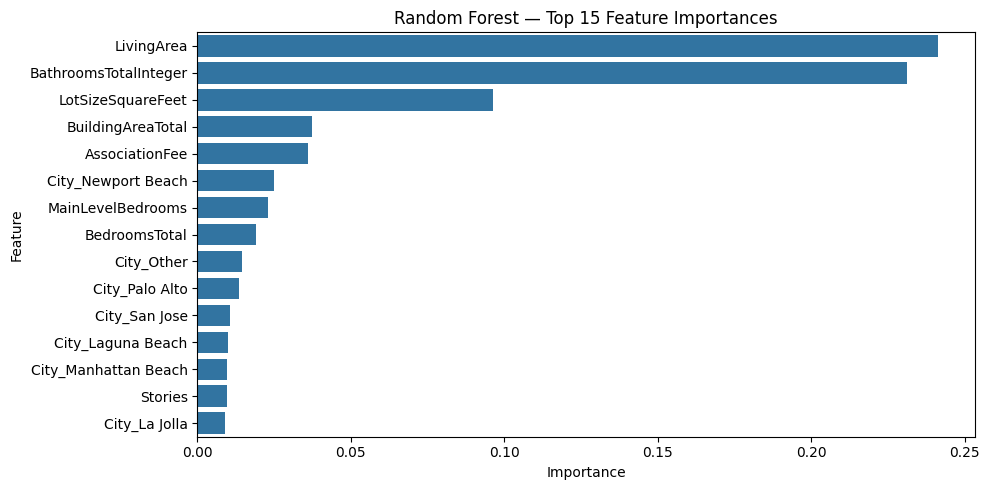

In [42]:
# Feature importance (top 15 non-city features)
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.show()

### 7.3 XGBoost

In [43]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb) * 100

print('=== XGBoost ===')
print(f'R²: {r2_xgb:.4f}')
print(f'MAPE: {mape_xgb:.2f}%')

=== XGBoost ===
R²:   0.7188
MAPE: 32.12%


## 8. Model Comparison

We summarize the performance of all three models on the held-out test set.

In [44]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R²': [r2_lr, r2_rf, r2_xgb],
    'MAPE (%)': [mape_lr, mape_rf, mape_xgb]
})
results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

            Model       R²  MAPE (%)
    Random Forest 0.729001 23.945726
          XGBoost 0.718823 32.116992
Linear Regression 0.679397 34.011211


In [46]:
results_final = test_set[['City', 'PostalCode', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger']].copy()
results_final['ActualClosePrice'] = y_test.values
results_final['PredictedClosePrice'] = y_pred_rf.round(0).astype(int)
results_final['Difference'] = results_final['PredictedClosePrice'] - results_final['ActualClosePrice']

results_final.head(10)

,City,PostalCode,LivingArea,BedroomsTotal,BathroomsTotalInteger,ActualClosePrice,PredictedClosePrice,Difference
19088,Walnut Creek,94596,2045.0,4.0,2.0,1998000.0,1571345,-426655.0
19090,Woodland Hills,91364,3050.0,4.0,4.0,2214421.0,1496696,-717725.0
19091,San Jose,95121,1594.0,4.0,2.0,1200000.0,1800030,600030.0
19095,San Jose,95124,2700.0,5.0,3.0,3100000.0,3032890,-67110.0
19097,San Jose,95128,2948.0,5.0,4.0,2900000.0,3048606,148606.0
19098,Mission Viejo,92692,1503.0,3.0,2.0,1050000.0,938084,-111916.0
19099,Concord,94519,1250.0,3.0,1.0,705000.0,761542,56542.0
19101,Temecula,92592,3574.0,5.0,4.0,1140000.0,1150010,10010.0
19102,San Francisco,94112,1656.0,3.0,3.0,914000.0,1675749,761749.0
19104,Laguna Beach,92651,1459.0,3.0,3.0,2500000.0,2513221,13221.0


## 9. Conclusion

### Model Performance Summary

| Model | R² | MAPE |
|---|---|---|
| Random Forest | 0.729 | 23.95% |
| XGBoost | 0.719 | 32.12% |
| Linear Regression | 0.679 | 34.01% |

### Key Findings

**Random Forest** was selected as the best model with an R² of 0.729 and MAPE of 23.95% on the December 2025 holdout — data the model never saw during training.

The single largest driver of improvement was adding **City** as a feature. Location is the dominant predictor of home prices in California, as confirmed by feature importance analysis where `BathroomsTotalInteger`, `LivingArea`, and city-based dummy variables ranked highest.